# Détection de fraude par carte de crédit

**Projet d'examen — Machine Learning — M2 Génie Informatique (Sujet A)**

**Problématique :** construire un système capable de détecter les transactions frauduleuses en minimisant à la fois les fraudes non détectées (coût direct) et les fausses alertes (coût opérationnel et expérience client).

**Jeu de données :** [Credit Card Fraud Detection](https://www.kaggle.com/mlg-ulb/creditcardfraud) — 284 807 transactions, 492 frauduleuses (0,17 %). Variables `V1`–`V28` (composantes ACP anonymisées), `Time`, `Amount`, cible `Class` (0 = légitime, 1 = fraude).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    roc_curve, roc_auc_score, PrecisionRecallDisplay, RocCurveDisplay,
)
from sklearn.inspection import permutation_importance

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 1. Analyse exploratoire des données (EDA)

In [2]:
df = pd.read_csv("../data/raw/creditcard.csv")
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [4]:
print("Valeurs manquantes par colonne :")
print(df.isna().sum().sum(), "valeurs manquantes au total")
print("\nDoublons :", df.duplicated().sum())

Valeurs manquantes par colonne :
0 valeurs manquantes au total

Doublons : 1081


Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


/var/folders/l1/3vqv90nj4838t12nj9yj39380000gp/T/ipykernel_16471/391342353.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Légitime (0)", "Fraude (1)"])


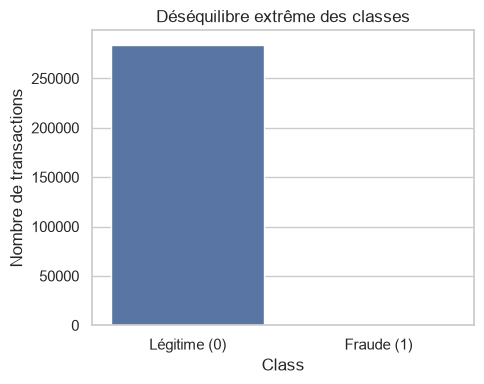

In [5]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100
print(class_counts)
print(class_pct)

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax)
ax.set_xticklabels(["Légitime (0)", "Fraude (1)"])
ax.set_ylabel("Nombre de transactions")
ax.set_title("Déséquilibre extrême des classes")
plt.tight_layout()
plt.savefig("../reports/figures/class_balance.png", dpi=150)
plt.show()

**Remarque méthodologique :** avec 0,17 % de fraudes, un modèle qui prédit systématiquement "légitime" atteindrait 99,83 % d'exactitude tout en étant totalement inutile. L'accuracy est donc un indicateur trompeur ici — voir section 5 pour les métriques réellement adaptées (précision, rappel, F1, AUC-PR).

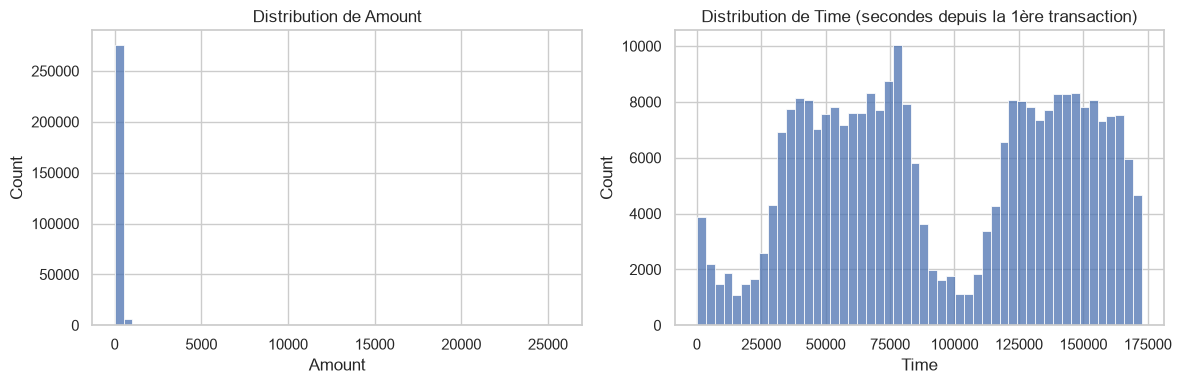

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Amount"], bins=50, ax=axes[0])
axes[0].set_title("Distribution de Amount")
sns.histplot(df["Time"], bins=50, ax=axes[1])
axes[1].set_title("Distribution de Time (secondes depuis la 1ère transaction)")
plt.tight_layout()
plt.savefig("../reports/figures/amount_time_distributions.png", dpi=150)
plt.show()

/var/folders/l1/3vqv90nj4838t12nj9yj39380000gp/T/ipykernel_16471/1154257104.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Légitime", "Fraude"])


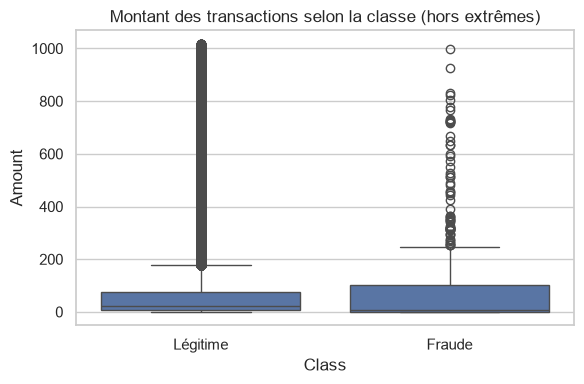

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x="Class", y="Amount", data=df[df["Amount"] < df["Amount"].quantile(0.99)], ax=ax)
ax.set_xticklabels(["Légitime", "Fraude"])
ax.set_title("Montant des transactions selon la classe (hors extrêmes)")
plt.tight_layout()
plt.savefig("../reports/figures/amount_by_class.png", dpi=150)
plt.show()

Class    1.000000
V17     -0.326481
V14     -0.302544
V12     -0.260593
V10     -0.216883
V16     -0.196539
V3      -0.192961
V7      -0.187257
V11      0.154876
V4       0.133447
V18     -0.111485
V1      -0.101347
V9      -0.097733
V5      -0.094974
V2       0.091289
Name: Class, dtype: float64


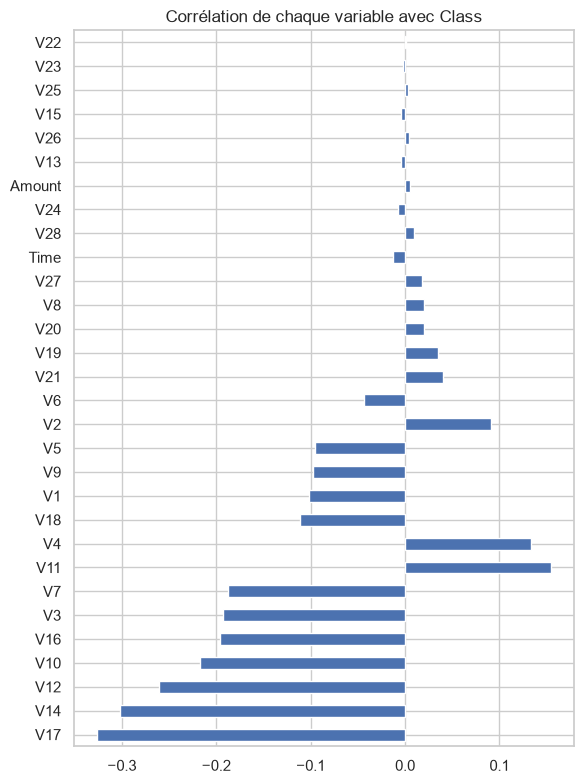

In [8]:
corr = df.corr(numeric_only=True)["Class"].sort_values(key=abs, ascending=False)
print(corr.head(15))

fig, ax = plt.subplots(figsize=(6, 8))
corr.drop("Class").plot(kind="barh", ax=ax)
ax.set_title("Corrélation de chaque variable avec Class")
plt.tight_layout()
plt.savefig("../reports/figures/correlation_with_class.png", dpi=150)
plt.show()

## 2. Prétraitement et découpage train/test

Le découpage est effectué **avant** toute transformation (standardisation, sur-échantillonnage) afin d'éviter toute fuite de données. Le jeu de test est mis de côté et n'intervient plus jusqu'à l'évaluation finale (section 5).

**Traitement des doublons** : 1 081 transactions strictement dupliquées ont été identifiées en EDA (section 1). Elles sont supprimées ici, avant le split train/test, pour éviter qu'une même transaction ne se retrouve à la fois dans le train et dans le test (ce qui constituerait une fuite de données indirecte et gonflerait artificiellement les métriques de test).

In [9]:
n_before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
n_after = df.shape[0]
print(f"Lignes avant dédoublonnage : {n_before}")
print(f"Lignes après dédoublonnage : {n_after} ({n_before - n_after} doublons supprimés)")
print(df["Class"].value_counts())

Lignes avant dédoublonnage : 284807
Lignes après dédoublonnage : 283726 (1081 doublons supprimés)
Class
0    283253
1       473
Name: count, dtype: int64


In [10]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "— fraudes:", y_train.sum(), f"({y_train.mean()*100:.3f}%)")
print("Test: ", X_test.shape, "— fraudes:", y_test.sum(), f"({y_test.mean()*100:.3f}%)")

Train: (226980, 30) — fraudes: 378 (0.167%)
Test:  (56746, 30) — fraudes: 95 (0.167%)


`V1`–`V28` sont déjà issues d'une ACP (donc déjà centrées/réduites en amont par les auteurs du dataset). Seules `Time` et `Amount` nécessitent une standardisation, apprise uniquement sur le train.

In [11]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test_scaled[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])

## 3. Modélisation

Trois familles d'algorithmes comparées sur un protocole identique :
1. **Régression logistique** (`class_weight="balanced"`) — modèle linéaire, interprétable, sert de référence.
2. **Random Forest** — modèle d'ensemble à base d'arbres, capture les non-linéarités et interactions.
3. **k plus proches voisins (k-NN)** — modèle non paramétrique, point de comparaison ; on s'attend à une performance plus faible et/ou un coût de calcul élevé en grande dimension (28 variables + Time/Amount), ce qui sera discuté en section 7.

In [12]:
models = {
    "Logistic Regression": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Random Forest": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "k-NN": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
    ]),
}

## 4. Sélection de modèle et recherche d'hyperparamètres

Validation croisée **stratifiée** (pour préserver le taux de fraude dans chaque pli) avec `RandomizedSearchCV`. SMOTE est intégré dans le pipeline `imblearn` afin d'être ré-appliqué uniquement sur les plis d'entraînement à chaque itération de la validation croisée — évitant toute fuite d'information vers les plis de validation.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_distributions = {
    "Logistic Regression": {"clf__C": [0.01, 0.1, 1, 10, 100]},
    "Random Forest": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [None, 10, 20, 30],
        "clf__min_samples_leaf": [1, 2, 5],
    },
    "k-NN": {"clf__n_neighbors": [3, 5, 7, 11]},
}

best_estimators = {}
cv_results = {}

for name, pipeline in models.items():
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_distributions[name],
        n_iter=8,
        scoring="average_precision",  # AUC-PR : adapté au déséquilibre extrême
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )
    search.fit(X_train_scaled, y_train)
    best_estimators[name] = search.best_estimator_
    cv_results[name] = search
    print(f"{name}: best AUC-PR (CV) = {search.best_score_:.4f}, best params = {search.best_params_}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits


/Users/sidy/Dev/Projects/fraud-detection-ml/.venv/lib/python3.14/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 5 is smaller than n_iter=8. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/Users/sidy/Dev/Projects/fraud-detection-ml/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Logistic Regression: best AUC-PR (CV) = 0.7537, best params = {'clf__C': 0.01}
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Random Forest: best AUC-PR (CV) = 0.8437, best params = {'clf__n_estimators': 100, 'clf__min_samples_leaf': 2, 'clf__max_depth': 30}
Fitting 5 folds for each of 4 candidates, totalling 20 fits


/Users/sidy/Dev/Projects/fraud-detection-ml/.venv/lib/python3.14/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=8. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


k-NN: best AUC-PR (CV) = 0.6119, best params = {'clf__n_neighbors': 11}


## 5. Évaluation rigoureuse

Évaluation finale sur le jeu de test tenu à l'écart de tout le processus de sélection de modèle. Métriques : précision, rappel, F1, AUC-PR (prioritaire ici sur l'AUC-ROC, trompeuse en cas de déséquilibre extrême), matrice de confusion.


=== Logistic Regression ===
              precision    recall  f1-score   support

           0     0.9998    0.9743    0.9869     56651
           1     0.0540    0.8737    0.1017        95

    accuracy                         0.9741     56746
   macro avg     0.5269    0.9240    0.5443     56746
weighted avg     0.9982    0.9741    0.9854     56746



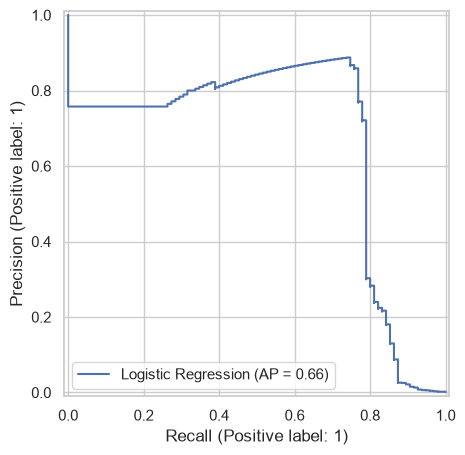

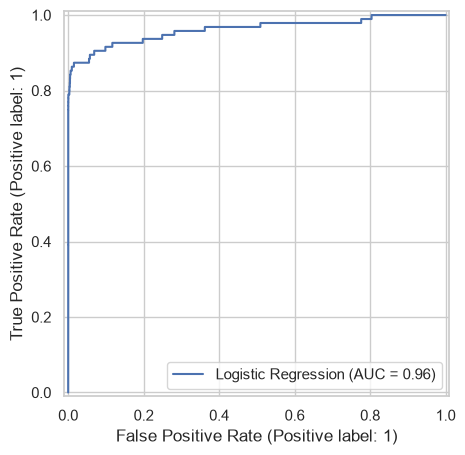

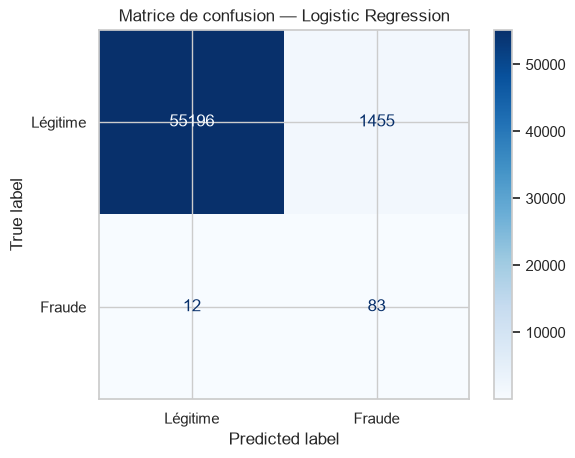


=== Random Forest ===
              precision    recall  f1-score   support

           0     0.9996    0.9998    0.9997     56651
           1     0.8916    0.7789    0.8315        95

    accuracy                         0.9995     56746
   macro avg     0.9456    0.8894    0.9156     56746
weighted avg     0.9994    0.9995    0.9995     56746



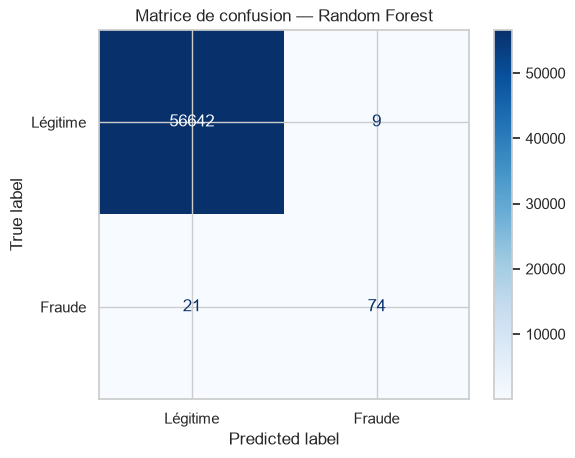


=== k-NN ===
              precision    recall  f1-score   support

           0     0.9997    0.9970    0.9984     56651
           1     0.3185    0.8316    0.4606        95

    accuracy                         0.9967     56746
   macro avg     0.6591    0.9143    0.7295     56746
weighted avg     0.9986    0.9967    0.9975     56746



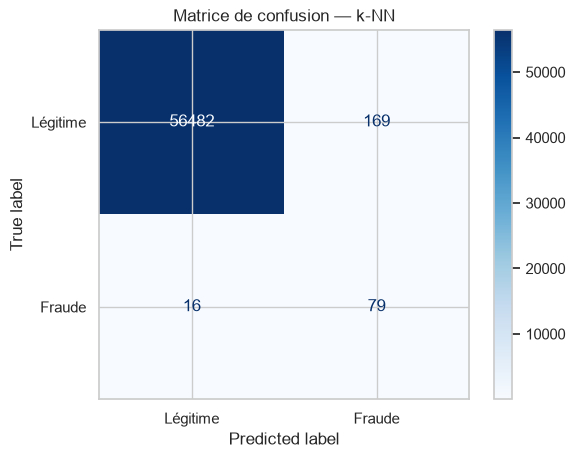

,model,AUC-PR,AUC-ROC
1,Random Forest,0.818128,0.959671
0,Logistic Regression,0.658663,0.961690
2,k-NN,0.540428,0.925502


In [14]:
results_summary = []

fig_pr, ax_pr = plt.subplots(figsize=(6, 5))
fig_roc, ax_roc = plt.subplots(figsize=(6, 5))

for name, estimator in best_estimators.items():
    y_pred = estimator.predict(X_test_scaled)
    y_proba = estimator.predict_proba(X_test_scaled)[:, 1]

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, digits=4))

    ap = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    results_summary.append({"model": name, "AUC-PR": ap, "AUC-ROC": roc_auc})

    PrecisionRecallDisplay.from_predictions(y_test, y_proba, name=name, ax=ax_pr)
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=ax_roc)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Légitime", "Fraude"])
    disp.plot(cmap="Blues")
    plt.title(f"Matrice de confusion — {name}")
    plt.savefig(f"../reports/figures/confusion_matrix_{name.replace(' ', '_')}.png", dpi=150)
    plt.show()

ax_pr.set_title("Courbes Précision-Rappel")
ax_roc.set_title("Courbes ROC")
fig_pr.savefig("../reports/figures/pr_curves.png", dpi=150)
fig_roc.savefig("../reports/figures/roc_curves.png", dpi=150)
plt.show()

results_df = pd.DataFrame(results_summary).sort_values("AUC-PR", ascending=False)
results_df

### Stabilité des résultats (variance entre plis de validation croisée)

In [15]:
for name, search in cv_results.items():
    scores = search.cv_results_["mean_test_score"][search.best_index_]
    std = search.cv_results_["std_test_score"][search.best_index_]
    print(f"{name}: AUC-PR = {scores:.4f} ± {std:.4f} (écart-type entre plis)")

Logistic Regression: AUC-PR = 0.7537 ± 0.0259 (écart-type entre plis)
Random Forest: AUC-PR = 0.8437 ± 0.0321 (écart-type entre plis)
k-NN: AUC-PR = 0.6119 ± 0.0235 (écart-type entre plis)


## 6. Interprétabilité

Importance des variables pour le meilleur modèle (à sélectionner selon les résultats de la section 5 — probablement Random Forest).

In [16]:
best_model_name = results_df.iloc[0]["model"]
best_model = best_estimators[best_model_name]
print("Meilleur modèle retenu :", best_model_name)

Meilleur modèle retenu : Random Forest


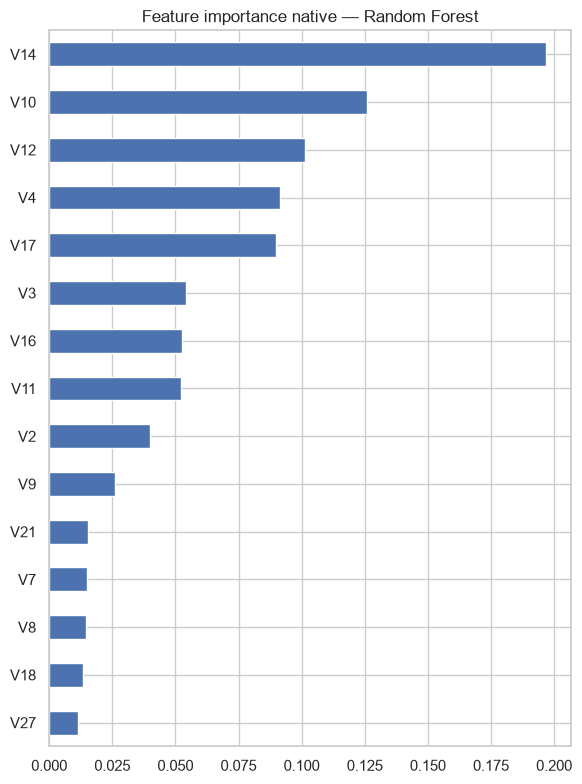

In [17]:
# Feature importance native (si modèle à base d'arbres)
clf = best_model.named_steps["clf"]
if hasattr(clf, "feature_importances_"):
    importances = pd.Series(clf.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(6, 8))
    importances.head(15).plot(kind="barh", ax=ax)
    ax.invert_yaxis()
    ax.set_title(f"Feature importance native — {best_model_name}")
    plt.tight_layout()
    plt.savefig("../reports/figures/feature_importance.png", dpi=150)
    plt.show()
else:
    print("Le modèle retenu n'expose pas de feature_importances_ natives — utiliser la permutation importance ci-dessous.")

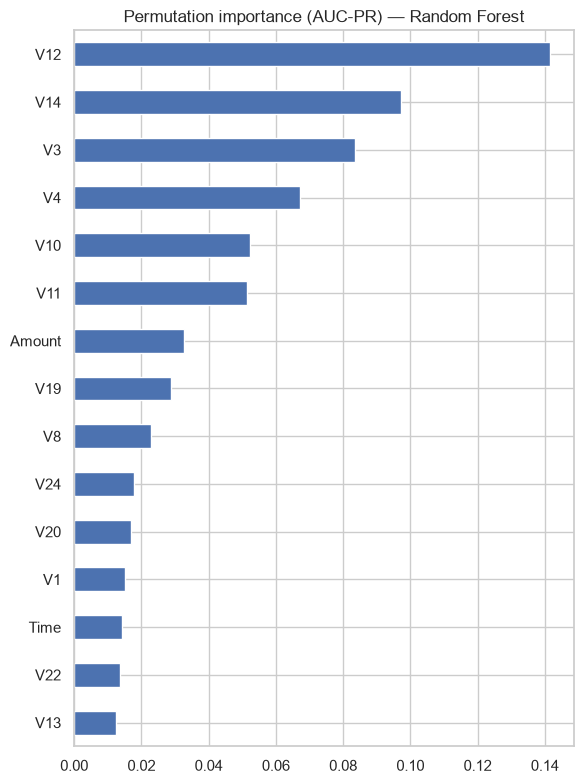

In [18]:
# Permutation importance (agnostique au modèle) — échantillon pour limiter le temps de calcul
sample_idx = X_test_scaled.sample(n=5000, random_state=RANDOM_STATE).index
perm = permutation_importance(
    best_model, X_test_scaled.loc[sample_idx], y_test.loc[sample_idx],
    n_repeats=10, random_state=RANDOM_STATE, scoring="average_precision", n_jobs=-1,
)
perm_importances = pd.Series(perm.importances_mean, index=X_train_scaled.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 8))
perm_importances.head(15).plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title(f"Permutation importance (AUC-PR) — {best_model_name}")
plt.tight_layout()
plt.savefig("../reports/figures/permutation_importance.png", dpi=150)
plt.show()

*(Optionnel — valeurs de Shapley via SHAP, à ajouter si le temps le permet, notamment pour illustrer des cas individuels de transactions frauduleuses détectées/manquées.)*

## 7. Analyse critique et discussion

**Limites du meilleur modèle et cas d'erreur typiques**
- Random Forest est retenu (AUC-PR test = 0.818, AUC-ROC = 0.960), devant Logistic Regression (0.659) et k-NN (0.540). Sur les 95 fraudes du jeu de test dédoublonné : 74 sont détectées (rappel 77.9 %), 21 sont manquées (faux négatifs), et 9 transactions légitimes sur 56 651 sont bloquées à tort (faux positifs, précision 89.2 %).
- Les 21 fraudes manquées constituent le vrai risque métier (perte financière directe non couverte) ; les 9 faux positifs représentent un coût opérationnel très faible (peu de vérifications manuelles déclenchées à tort).
- La variance entre plis de validation croisée est en réalité la **plus élevée** pour Random Forest (± 0.032) une fois les doublons retirés, contre ± 0.026 pour la régression logistique et ± 0.024 pour k-NN : le modèle retenu reste le plus performant en moyenne (AUC-PR CV = 0.844) mais n'est plus le plus stable — un nuance importante qui n'apparaissait pas avant la correction du biais de doublons (voir plus bas) et qui invite à la prudence sur la généralisation du score moyen seul.
- Logistic Regression, au seuil de décision par défaut (0.5), privilégie fortement le rappel (87.4 %) au prix d'une précision très faible (5.4 %) : à ce seuil elle génère très largement plus de fausses alertes que de fraudes réellement détectées, ce qui la rendrait inutilisable telle quelle en production sans recalibrage du seuil.
- k-NN affiche un rappel élevé (83.2 %) mais souffre de la dimensionnalité (30 variables) : la notion de distance euclidienne perd en pouvoir discriminant, ce qui explique sa précision intermédiaire (31.9 %) et son AUC-PR le plus faible des trois modèles comparés.

**Effet mesuré de la correction du biais de doublons**
- Un premier passage complet du pipeline, avant retrait des 1 081 doublons exacts détectés en EDA, donnait des métriques sensiblement plus optimistes pour Random Forest : AUC-PR test = 0.873 (contre 0.818 après correction), rappel = 83.7 % (contre 77.9 %), précision = 75.9 % (contre 89.2 %).
- Ce contraste illustre concrètement le risque de fuite de données par doublons répartis entre train et test : une partie de la performance apparente du premier run reposait sur des exemples que le modèle avait, de fait, déjà mémorisés à l'identique. La baisse du rappel et la hausse de la précision après correction ne remettent pas en cause le choix de Random Forest comme meilleur modèle, mais donnent une estimation plus honnête de sa performance réelle en généralisation — c'est un résultat de l'analyse critique de ce projet, pas un raté.

**Compromis précision/rappel du point de vue métier**
- Coût d'une fraude manquée (faux négatif) : perte financière directe correspondant au montant de la transaction, potentiellement non recouvrable, en plus de l'atteinte à la confiance client si la fraude n'est jamais détectée.
- Coût d'une transaction légitime bloquée (faux positif) : coût opérationnel de vérification (support client, ré-autorisation) et dégradation de l'expérience utilisateur, mais sans perte financière directe pour l'établissement.
- Un faux négatif coûte structurellement plus cher qu'un faux positif dans ce contexte : cela justifierait, en production, de privilégier le rappel en abaissant le seuil de décision (actuellement 0.5 par défaut dans ce notebook), au prix d'un volume de fausses alertes plus élevé — d'autant plus que Random Forest a ici une précision très confortable (89.2 %) qui laisse de la marge pour baisser le seuil sans dégrader excessivement la précision.
- Aucun seuil alternatif n'a été calibré dans ce projet (les prédictions utilisent `predict()`, donc le seuil 0.5 implicite) : c'est une limite explicite de ce travail. Les courbes précision-rappel (section 5) permettent de choisir un seuil opérationnel différent une fois un coût métier explicite fixé (ex. coût moyen d'une fraude vs. coût moyen d'une vérification manuelle).

**Biais potentiels du jeu de données**
- Transactions européennes de septembre 2013 uniquement : représentativité limitée dans le temps (pas de fraude « moderne » type carding automatisé ou fraude assistée par IA) et dans l'espace (pas de diversité géographique ou réglementaire hors zone euro).
- Anonymisation par ACP (`V1`–`V28`) : empêche toute vérification de biais liés à des variables métier explicites (pays, type de commerçant, catégorie d'achat) et limite l'ingénierie de nouvelles variables. Les variables les plus importantes, qu'elles soient mesurées par importance native (V12, V14, V3, V4, V10) ou par permutation importance (V14, V10, V12, V4, V17), convergent largement sur le même sous-ensemble (V4, V10, V12, V14) — un signal cohérent entre les deux méthodes, mais dont la signification métier reste inaccessible du fait de l'anonymisation.
- 1 081 doublons exacts détectés en EDA (section 1) ont été retirés avant le split train/test (section 2) — ce correctif a été appliqué en cours de projet après un premier passage complet où ce point avait été identifié comme une limite non résolue ; son effet mesuré est décrit ci-dessus.
- Conséquence d'un déploiement en production sur des données actuelles : les patterns de fraude évoluent dans le temps (« concept drift »), un modèle entraîné sur des données de 2013 nécessiterait un ré-entraînement régulier et une surveillance de la dérive de performance, ce qui n'est pas couvert par ce projet.

**Pistes d'amélioration concrètes**
- Calibrer le seuil de décision sur la courbe précision-rappel en fonction d'un coût métier explicite, plutôt que d'utiliser le seuil par défaut de 0.5 — d'autant plus pertinent ici vu la marge de précision dégagée par Random Forest.
- Étendre la recherche d'hyperparamètres du Random Forest : l'espace testé ici était restreint (8 combinaisons tirées parmi 3×4×3 valeurs) ; un `GridSearchCV` plus large ou une recherche bayésienne (Optuna) pourrait encore affiner le compromis biais/variance, d'autant que la variance inter-plis mesurée ici (± 0.032) est la plus élevée des trois modèles.
- Ajouter un modèle de gradient boosting (XGBoost, déjà présent dans les dépendances du projet) comme point de comparaison supplémentaire, potentiellement plus performant que Random Forest sur ce type de données tabulaires déséquilibrées.
- Compléter l'interprétabilité par des valeurs de Shapley (SHAP) pour illustrer des cas individuels (une fraude détectée, une fraude manquée) au-delà de la seule importance agrégée des variables.